$$
\begin{gather*}
\text{Se importan las librerías necesarias}
\end{gather*}
$$

In [10]:
import numpy as np
import matplotlib.pyplot as plt

Para representar gráficamente cada uno de los elementos de la figura, se utiliza la parametrización de una circunferencia:

1. **Muestreo Angular ($\theta$):** Se generan 400 puntos distribuidos uniformemente en el intervalo $[0, 2\pi]$ mediante `np.linspace` para definir la resolución y suavidad de cada círculo.
2. **Transformación a Coordenadas Cartesianas:** Se calculan las posiciones de los puntos mediante las identidades trigonométricas, ajustadas por el radio ($r$) y el centro ($x_c, y_c$):
   $$x = r \cdot \cos(\theta) + x_c$$
   $$y = r \cdot \sin(\theta) + y_c$$
3. **Visualización y Proporción:** Se utiliza `plt.plot` para renderizar el trazo y se define un `plt.figure(figsize=(8,8))` para asegurar una relación de aspecto $1:1$, evitando que la geometría circular se deforme por el escalado del lienzo.

In [11]:
def dibujar_circulo(r, xc, yc):
    theta = np.linspace(0, 2*np.pi, 400)
    x = r * np.cos(theta) + xc
    y = r * np.sin(theta) + yc
    plt.plot(x, y)

plt.figure(figsize=(8,8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

1. Se generan un total de **40,000 puntos** en un ciclo for, calculados mediante funciones matemáticas para definir la mariposa.

In [12]:
num_circulos = 40000

### Ecuaciones Paramétricas de la Mariposa

Para la generación de la estructura de la mariposa, se utilizan las siguientes ecuaciones para determinar las coordenadas del centro ($x_c, y_c$) y el radio ($r$) de cada uno de los 40,000 elementos:

**Coordenada $x_c$:**
$$
\begin{aligned}
x_c = \frac{3}{2} \cos^9\left(\frac{141\pi k}{40000}\right) \left[1 - \frac{1}{2}\sin\left(\frac{\pi k}{40000}\right)\right] 
\left[1 - \frac{1}{4}\cos^{30}\left(\frac{2\pi k}{40000}\right) \left(1 + \cos^{20}\left(\frac{32\pi k}{40000}\right)\right)\right] \\
\times \left[1 - \frac{1}{2}\sin^{30}\left(\frac{2\pi k}{40000}\right) \sin^{10}\left(\frac{6\pi k}{40000}\right) \left(\frac{1}{2} + \frac{1}{2}\sin^{20}\left(\frac{18\pi k}{40000}\right)\right)\right]
\end{aligned}
$$

**Coordenada $y_c$:**
$$
y_c = \cos\left(\frac{2\pi k}{40000}\right) \cos^2\left(\frac{141\pi k}{40000}\right) \left[1 + \frac{1}{4} \left(\cos\frac{\pi k}{40000} \cos\frac{3\pi k}{40000} \cos\frac{21\pi k}{40000}\right)^{24}\right]
$$

**Cálculo del Radio ($r$):**
$$
r = \frac{1}{40} \left[\cos^{14}\left(\frac{141\pi k}{40000}\right) + \sin^6\left(\frac{141\pi k}{40000}\right)\right] \left[1 - \left(\cos\frac{\pi k}{40000} \cos\frac{3\pi k}{40000} \cos\frac{12\pi k}{40000}\right)^{16}\right] + \frac{1}{100}
$$

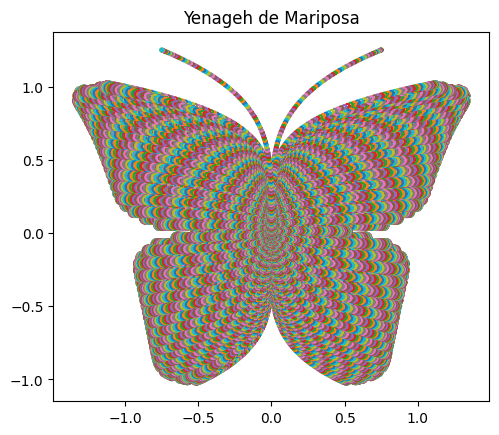

In [13]:
for k in range(num_circulos):
    xc = (3/2) * (np.cos(141*np.pi*k/40000))**9 * \
     (1 - (1/2)*np.sin(np.pi*k/40000)) * \
     \
     (1 - (1/4)*((np.cos(2*np.pi*k/40000))**30) * \
     (1 + (np.cos(32*np.pi*k/40000))**20)) * \
     \
     (1 - (1/2)*((np.sin(2*np.pi*k/40000))**30) * \
     ((np.sin(6*np.pi*k/40000))**10) * \
     ((1/2 + (1/2)*(np.sin(18*np.pi*k/40000))**20)) \
     )

    yc = np.cos(2*np.pi*k/40000) * \
     (np.cos(141*np.pi*k/40000))**2 * \
     (1 + (1/4) * (np.cos(np.pi*k/40000) * \
                   np.cos(3*np.pi*k/40000) * \
                   np.cos(21*np.pi*k/40000))**24)

    radio = (1/40) * (
    (np.cos(141*np.pi*k/40000))**14 + (np.sin(141*np.pi*k/40000))**6
) * (
    1 - (
        np.cos(np.pi*k/40000) * np.cos(3*np.pi*k/40000) * np.cos(12*np.pi*k/40000)
    )**16
) + (1/100)

    dibujar_circulo(radio, xc, yc)

plt.gca().set_aspect("equal", "box")
plt.title("Yenageh de Mariposa")
plt.savefig("../assets/Butterfly.png", dpi=300)
plt.show()

